In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

In [3]:
import ollama
import json
import pandas as pd
import re
import requests

from iterative_eval_utils import (
    compute_bertscore_batched,
    run_resumable_evaluation,
)
from retrieval_guardrails import DEFAULT_POLICY, is_allowed_document


In [4]:
# Load QULAC dataset from JSON file
# file contains queries, clarification questions, and metadata

url = "https://raw.githubusercontent.com/raina-joshi/llm-followup-thesis/main/qulac.json"
data = requests.get(url).json()

# convert to rows
df = pd.DataFrame(data)

In [6]:
# print column names
print(df.columns)

Index(['topic_id', 'facet_id', 'topic_facet_id', 'topic_facet_question_id',
       'topic', 'topic_type', 'facet_type', 'topic_desc', 'facet_desc',
       'question', 'answer'],
      dtype='object')


In [7]:
# print first row
df.iloc[0]

topic_id                                                                   1
facet_id                                                                   1
topic_facet_id                                                           1-1
topic_facet_question_id                                                1-1-1
topic                                                      obama family tree
topic_type                                                           faceted
facet_type                                                               nav
topic_desc                 Find information on President Barack Obama\'s ...
facet_desc                 Find the TIME magazine photo essay \"Barack Ob...
question                   are you interested in seeing barack obamas family
answer                                    yes am interested in obamas family
Name: 0, dtype: object

In [8]:
# unique queries
unique_queries = df[['topic_id', 'topic']].drop_duplicates()

sample_queries = unique_queries.sample(n=30, random_state=42)

original_df = df[df['topic_id'].isin(sample_queries['topic_id'])]

# Reset index
original_df  = original_df.reset_index(drop=True)
original_df['ID'] = original_df.index + 1

original_df = original_df[['ID', 'topic_id', 'topic', 'question', 'answer', 'topic_type', 'facet_type']]

pd.set_option('display.max_colwidth', None)
display(original_df.head(10))

,ID,topic_id,topic,question,answer,topic_type,facet_type
0,1,108,ralph owen brewster,are you interested in learning more about ralph owen brewseter,yes and his biography,faceted,inf
1,2,108,ralph owen brewster,would you like to know the political positions ralph owen brewster held,yes,faceted,inf
2,3,108,ralph owen brewster,would you like to know what movie star portrayed brewster in the movie the aviator and what award the movie star was nominated for the performance,no,faceted,inf
3,4,108,ralph owen brewster,would you like to know what political party ralph owen brewster was affiliated with,yes and other information about him,faceted,inf
4,5,108,ralph owen brewster,how old is ralph owen brewseter,yes,faceted,inf
5,6,108,ralph owen brewster,may i provide you with information regarding when ralph owen brewster died and cause of death,yes please also include general biographical info too,faceted,inf
6,7,108,ralph owen brewster,may i tell you about brewsters parents where and when he was born,yes i am interested in all biographical information about ralph owen brewster,faceted,inf
7,8,108,ralph owen brewster,what is ralph owen brewser famous for,yes that is part fo what im looking for,faceted,inf
8,9,108,ralph owen brewster,what is ralph owen brewsters background,i dont know,faceted,inf
9,10,108,ralph owen brewster,what is ralph owen brewsters education,please answeers this and give me more information,faceted,inf


In [9]:
sample_df = unique_queries.copy()

In [10]:
print("Total rows:", len(sample_df))
print("Unique topics:", sample_df["topic"].nunique())

Total rows: 198
Unique topics: 198


In [9]:
# get wikipedia docs for a query
import wikipedia

def get_wiki_docs(query, top_k=5, policy=DEFAULT_POLICY):
    docs = []

    try:
        titles = wikipedia.search(query, results=top_k * 3)

        for title in titles:
            try:
                page = wikipedia.page(title, auto_suggest=False)
                if not is_allowed_document(page.title, page.summary, policy=policy):
                    continue
                docs.append({
                    "title": page.title,
                    "summary": page.summary
                })
                if len(docs) >= top_k:
                    break
            except:
                continue

    except:
        pass

    return docs

In [169]:
fixed_test_queries = [
    "flushing",
    "milwaukee journal sentinel",
    "bart sf"
]

for i, query in enumerate(fixed_test_queries, 1):
    raw_docs = get_wiki_docs(query)
    print(f"{i}. {query}")
    print([doc["title"] for doc in raw_docs])
    print("------")

1. flushing
['Flushing, Queens', 'Flushing Meadows–Corona Park', 'Flushing (physiology)', 'Flush toilet', 'Alcohol flush reaction']
------
2. milwaukee journal sentinel
['Milwaukee Journal Sentinel', 'American Family Field', 'WDJT-TV', 'Milwaukee', '2025 Milwaukee area floods']
------
3. bart sf
['Bay Area Rapid Transit', 'Joey Bart', 'San Francisco International Airport station', 'Killing of Oscar Grant', 'Embarcadero station']
------


In [168]:
# compute once per unique topic
topic_to_docs = {
    topic: get_wiki_docs(topic)
    for topic in sample_df['topic'].unique()
}

# map back
sample_df['retrieved_docs'] = sample_df['topic'].map(topic_to_docs)

pd.set_option('display.max_colwidth', None)
print(sample_df[['topic', 'retrieved_docs']].head(3))

                           topic  \
0              obama family tree   
39                cheap internet   
129  ritz carlton lake las vegas   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [ ]:
def filter_relevant_docs(query, docs, policy=DEFAULT_POLICY):   
    import re

    def normalize(text):
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    query_norm = normalize(query)
    query_words = [
        w for w in query_norm.split()
        if w not in {"the", "and", "of", "to", "in", "for", "on", "a", "an"}
        and len(w) > 2
    ]

    generic_query = len(query_words) <= 2
    scored_docs = []

    for doc in docs:
        if isinstance(doc, dict):
            title = doc.get("title", "")
            summary = doc.get("summary", "")
        else:
            title = ""
            summary = str(doc)

        if not is_allowed_document(title, summary, policy=policy):
            continue

        title_norm = normalize(title)
        doc_norm = normalize(summary)

        lexical_score = sum(1 for w in query_words if w in doc_norm)
        title_score = sum(2 for w in query_words if w in title_norm)
        score = lexical_score + title_score

        if generic_query and (" in " in title_norm or " list of " in title_norm):
            score -= 2

        prompt = f"""
        Query: {query}

        Document title:
        {title}

        Document:
        {summary[:1200]}

        Task:
        Is this document directly relevant to answering the query?

        Rules:
        - Prefer documents about the exact entity or topic in the query.
        - For generic queries, prefer broad topic pages over location-specific pages.
        - Reject documents that only match one common word.
        - Reject policy-disallowed or academically unsuitable documents.
        - Answer YES only if the document is clearly about the same topic.

        Answer ONLY:
        YES or NO
        """

        response = ollama.chat(
            model='llama3.2:3b',
            messages=[{'role': 'user', 'content': prompt}],
            options={'num_predict': 5, 'temperature': 0}
        )

        ans = response['message']['content'].strip().upper()

        if "YES" in ans and score > 0:
            scored_docs.append((score, summary))

    scored_docs = sorted(scored_docs, key=lambda x: x[0], reverse=True)
    filtered = [doc for _, doc in scored_docs[:3]]

    if filtered:
        return filtered

    lexical_fallback = []
    for doc in docs:
        if isinstance(doc, dict):
            title = doc.get("title", "")
            summary = doc.get("summary", "")
        else:
            title = ""
            summary = str(doc)

        if not is_allowed_document(title, summary, policy=policy):
            continue

        title_norm = normalize(title)
        doc_norm = normalize(summary)
        score = sum(1 for w in query_words if w in doc_norm) + sum(2 for w in query_words if w in title_norm)
        if generic_query and (" in " in title_norm or " list of " in title_norm):
            score -= 2
        if score > 0:
            lexical_fallback.append((score, summary))

    lexical_fallback = sorted(lexical_fallback, key=lambda x: x[0], reverse=True)
    if lexical_fallback:
        return [doc for _, doc in lexical_fallback[:2]]

    if docs:
        first_doc = docs[0]
        if isinstance(first_doc, dict) and is_allowed_document(first_doc.get("title", ""), first_doc.get("summary", ""), policy=policy):
            return [first_doc.get("summary", "")]
        if not isinstance(first_doc, dict) and is_allowed_document("", str(first_doc), policy=policy):
            return [str(first_doc)]

    return []

In [13]:
# detect ambiguity BEFORE answer generation
def detect_ambiguity(query):
    query = query.strip()

    # well-formed named entities usually do not need intent clarification
    if len(query.split()) >= 3 and query.replace(" ", "").isalpha():
        return False

    prompt = f"""
    Query: {query}

    Does this query have multiple meanings or interpretations,
    or is it missing the intent needed to answer it correctly?

    Answer only: YES or NO
    """

    response = ollama.chat(
        model='llama3.2:3b',
        messages=[{'role': 'user', 'content': prompt}],
        options={'num_predict': 5, 'temperature': 0}
    )

    return "YES" in response['message']['content'].upper()

In [ ]:
# Generate answer
def generate_answer(question, docs, original_query=None):
    import re

    if not docs:
        return "Insufficient information"

    topic = original_query or question
    context = "\n\n".join([f"Doc{i+1}: {doc[:900]}" for i, doc in enumerate(docs[:2])])

    prompt = f"""
    You are answering a question using ONLY the provided context.

    Topic:
    {topic}

    Question to answer:
    {question}

    STRICT RULES:
    - Use ONLY facts from the context.
    - Keep the answer anchored to the topic.
    - Ignore unrelated facts even if they appear in the context.
    - Do NOT combine unrelated entities or topics.
    - If the context does not support the answer, say: "Insufficient information".
    - If the topic is ambiguous and the context does not resolve it, say: "Ambiguous query".

    RESPONSE RULES:
    - Write 1 or 2 complete sentences only.
    - Answer the question directly.
    - Do not trail off.
    - Do not guess.
    - Do not contradict the context.

    Context:
    {context}

    Answer:
    """

    response = ollama.chat(
        model='llama3.2:3b',
        messages=[{'role': 'user', 'content': prompt}],
        options={
            'num_predict': 70,
            'temperature': 0
        }
    )

    answer = response['message'].get('content', '').strip()
    answer = re.sub(r'\s+', ' ', answer).strip()

    bad_patterns = [
        "user might be looking",
        "the query",
        "it can be inferred",
        "this suggests",
        "likely",
        "generally",
        "typically",
        "in most cases",
        "it seems"
    ]

    if len(answer.split()) < 5:
        return "Insufficient information"

    if any(pattern in answer.lower() for pattern in bad_patterns):
        return "Insufficient information"

    if not answer.endswith(('.', '!', '?')):
        answer += '.'

    sentences = re.split(r'(?<=[.!?])\s+', answer)
    cleaned = []
    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue
        cleaned.append(sentence)
        if len(cleaned) == 2:
            break

    final_answer = ' '.join(cleaned).strip()

    if not final_answer or len(final_answer.split()) < 5:
        return "Insufficient information"

    return final_answer

In [17]:
# random sample of 3
test_df = sample_df.sample(n=3, random_state=42).copy()

answers = []

for _, row in test_df.iterrows():
    query = row['topic']

    raw_docs = get_wiki_docs(query)
    filtered_docs = filter_relevant_docs(query, raw_docs)

    ans = generate_answer(query, filtered_docs)
    answers.append(ans)

test_df['answer'] = answers

In [18]:
from IPython.display import display
pd.set_option('display.max_colwidth', None)
display(test_df[['topic', 'answer']])

,topic,answer
65,flushing,"Flushing is a neighborhood in Queens, New York City. It has been a settlement since 1645 and was consolidated into the City of Greater New York in 1898."
114,milwaukee journal sentinel,"The Milwaukee Journal Sentinel is a daily morning broadsheet printed in Milwaukee, Wisconsin. It is the primary newspaper and also the largest newspaper in the state of Wisconsin."
16,bart sf,"There is no direct connection between ""bart sf"" and the provided context. Insufficient information."


In [19]:
# Baseline follow-up generation (plain prompting)

def ensure_question(text, query):
    text = str(text).strip()
    text = text.replace("Question:", "").replace("Follow-up", "").replace(":", "").strip()
    text = " ".join(text.split())

    if not text:
        return f"What specific information are you looking for about {query}?"

    if "?" in text:
        text = text.split("?")[0].strip() + "?"
        return text

    lowered = text.lower()
    if lowered.startswith(("what ", "which ", "who ", "where ", "when ", "why ", "how ", "are ", "is ", "do ", "does ", "did ", "can ", "could ", "would ", "should ")):
        return text.rstrip(".!") + "?"

    if lowered.endswith(" is") or lowered.endswith(" are"):
        return text.rstrip(".!") + "?"

    return f"What specific information are you looking for about {query}?"


def generate_baseline_followup(query):
    prompt = f"""
    Generate ONE useful follow-up question to clarify the query.

    Rules:
    - Ask about a specific missing detail (e.g., location, type, features, time, etc.)
    - Do NOT ask vague questions like "What do you want to know?"
    - The question must narrow down the query and be relevant to the original query and potential information needs.
    - Frame the output as a question.
    - The output must end with a question mark.
    - Do not answer the query.
    - Do not complete the sentence as a statement.

    Query: {query}

    Return ONLY the question.
    """

    response = ollama.chat(
        model='llama3.2:3b',
        messages=[{'role': 'user', 'content': prompt}],
        options={'num_predict': 50, 'temperature': 0}
    )

    msg = response['message']
    text = msg.get('content', '').strip()

    return ensure_question(text, query)


In [ ]:
# test baseline: single-shot follow-up generation
test_df = sample_df.sample(n=3, random_state=42).copy()

for i, row in test_df.iterrows():
    query = row['topic']
    followup = generate_baseline_followup(query)

    print(f"Query: {query}")
    print(f"Baseline: {followup}")
    print("-" * 50)

Query: flushing
Baseline: Is there a specific context or industry (e.g. plumbing, environmental, etc.) where you would like to know more about flushing?
--------------------------------------------------
Query: milwaukee journal sentinel
Baseline: Is the Milwaukee Journal Sentinel primarily a print or online publication?
--------------------------------------------------
Query: bart sf
Baseline: Is "Bart SF" referring to a specific location, event, or entity related to Bart Simpson, and if so, what is the connection to San Francisco?
--------------------------------------------------


In [77]:
# Baseline: Decomposition (Parallel)
def generate_decomposition_followup(query):
    prompt = f"""
    Generate 3 different follow-up questions about the query, each focusing on a different aspect.

    Examples of aspects:
    - what/who it is
    - role, function, or purpose
    - history, location, or usage

    Rules:
    - Each question must be specific and useful
    - Do NOT ask generic questions like "What do you want to know?"
    - Do NOT repeat the same idea
    - Keep questions simple and relevant

    Query: {query}

    Return ONLY 3 questions, each on a new line.
    """

    response = ollama.chat(
        model='llama3.2:3b',
        messages=[{'role': 'user', 'content': prompt}],
        options={'num_predict': 100, 'temperature': 0}
    )

    text = response['message']['content'].strip()

    # split lines and pick first valid question
    lines = [re.sub(r"^\d+[\.\)]\s*", "", l.strip()) for l in text.split("\n") if l.strip()]

    valid = []
    for l in lines:
        q = ensure_question(l, query)

        # remove generic fallback
        if "what specific information" in q.lower():
            continue

        # avoid super short junk
        if len(q.split()) < 4:
            continue

        valid.append(q)

    if valid:
        return valid[0]

    return ensure_question("", query)

In [78]:
# test baseline decomposition follow-up generation
test_df = sample_df.sample(n=3, random_state=42).copy()
for i, row in test_df.iterrows():
    query = row['topic']
    followup = generate_decomposition_followup(query)

    print(f"Query: {query}")
    print(f"Decomp: {followup}")
    print("-" * 50)

Query: flushing
Decomp: What is the primary purpose of flushing in plumbing systems?
--------------------------------------------------
Query: milwaukee journal sentinel
Decomp: What is the current ownership structure of the Milwaukee Journal Sentinel?
--------------------------------------------------
Query: bart sf
Decomp: What is Bart SF?
--------------------------------------------------


In [85]:
# Baseline: Yes/No (Claim-style)
def generate_yesno_followup(query):
    prompt = f"""
    Generate ONE yes/no follow-up question to clarify the query.

    Rules:
    - The question must be answerable with ONLY "yes" or "no"
    - Do NOT ask multiple-choice questions
    - Do NOT include "or" comparisons (e.g., person, place, or thing)
    - Do NOT assume specific facts
    - Keep it simple and relevant

    Query: {query}

    Return ONLY the question.
    """

    response = ollama.chat(
        model='llama3.2:3b',
        messages=[{'role': 'user', 'content': prompt}],
        options={'num_predict': 50, 'temperature': 0}
    )

    text = response['message']['content'].strip()

    if " or " in text.lower():
        return ensure_question("", query)

    return ensure_question(text, query)

In [86]:
# test yes/no follow-up question
test_df = sample_df.sample(n=3, random_state=42).copy()
for i, row in test_df.iterrows():
    query = row['topic']
    followup = generate_yesno_followup(query)

    print(f"Query: {query}")
    print(f"Yes/No: {followup}")
    print("-" * 50)

Query: flushing
Yes/No: Is toilet flushing a common practice worldwide?
--------------------------------------------------
Query: milwaukee journal sentinel
Yes/No: Is the Milwaukee Journal Sentinel a daily newspaper?
--------------------------------------------------
Query: bart sf
Yes/No: Is Bart a character from The Simpsons?
--------------------------------------------------


In [87]:
# Aspect extraction
def extract_aspects(query):
    import re

    query_clean = str(query).strip()
    query_lower = query_clean.lower()
    words = [w for w in re.findall(r"[a-zA-Z0-9]+", query_clean) if len(w) > 1]

    def has_any(phrases):
        return any(p in query_lower for p in phrases)

    def classify_query_type(text):
        text_lower = text.lower().strip()
        tokens = [w for w in re.findall(r"[a-zA-Z0-9]+", text_lower) if len(w) > 1]

        if len(tokens) <= 2:
            return "ambiguous_short_query"

        if has_any(["family tree", "ancestry", "genealogy"]):
            return "family_relationship"

        if has_any(["hotel", "resort", "inn", "airport", "terminal", "airlines"]):
            return "place_or_facility"

        if has_any(["restaurant", "museum", "university", "company", "organization", "school", "farm"]):
            return "organization_or_place"

        if has_any(["cheap", "best", "budget", "affordable", "price", "pricing", "cost", "provider", "plan"]):
            return "service_or_product"

        if has_any(["map", "located", "location", "address", "directions", "where is"]):
            return "place_or_location"

        if has_any(["who won", "biography", "born", "died", "who is", "who was"]):
            return "person"

        # Broad person-name heuristic without memorizing topic-specific exceptions.
        title_cased = [part for part in re.split(r"\s+", text.strip()) if part]
        if 2 <= len(title_cased) <= 4 and all(part[:1].isalpha() for part in title_cased):
            non_person_markers = {
                "airport", "hotel", "resort", "museum", "restaurant", "company",
                "university", "school", "farm", "lake", "park", "internet",
                "family", "tree", "map", "disease", "county", "tourism"
            }
            if not any(token in non_person_markers for token in tokens):
                return "person"

        if has_any(["disease", "symptoms", "treatment", "causes"]):
            return "topic_or_condition"

        if has_any(["album", "movie", "film", "book", "song", "game"]):
            return "work_or_media"

        return "generic"

    query_type = classify_query_type(query_clean)

    aspect_priors = {
        "family_relationship": ["family members", "ancestry", "relationships"],
        "service_or_product": ["type or option", "pricing or availability", "features or providers"],
        "place_or_facility": ["location", "services or amenities", "current status"],
        "place_or_location": ["location", "key features", "relevance or use"],
        "organization_or_place": ["main purpose or type", "location", "notable features"],
        "person": ["identity", "role or career", "notable contribution"],
        "topic_or_condition": ["definition or type", "causes or features", "diagnosis or treatment"],
        "work_or_media": ["work identity", "content or subject", "notable significance"],
        "ambiguous_short_query": ["intended meaning", "context", "specific need"],
    }

    if query_type in aspect_priors:
        return aspect_priors[query_type]

    prompt = f"""
    Identify 3 key aspects needed to answer this query well.

    An aspect is a dimension of information required to satisfy the query,
    including implicit missing information when relevant.

    Rules:
    - exactly 3 aspects
    - short phrases only
    - 2 to 5 words each
    - no full sentences
    - avoid generic items like "details", "information", "major achievements", or "historical significance"
    - prefer aspects that help generate useful follow-up questions for this specific query type
    - if the query is about a person, use person-style aspects only when appropriate
    - if the query is about a place, organization, service, or object, do NOT use person-style aspects

    Query: {query_clean}

    Aspects:
    """
    response = ollama.chat(
        model='llama3.2:3b',
        messages=[{'role': 'user', 'content': prompt}],
        options={'num_predict': 80, 'temperature': 0}
    )

    def clean_aspects(text):
        lines = text.split("\n")
        cleaned = []
        banned = {
            "details", "information", "general information", "overview", "background",
            "major achievements", "historical significance"
        }

        for line in lines:
            line = line.strip()
            line = line.lstrip("1234567890.-) ").strip()
            line = re.sub(r'[^a-zA-Z0-9\s/&-]', '', line).strip()

            if not line:
                continue
            if len(line.split()) < 1 or len(line.split()) > 6:
                continue
            if line.lower() in banned:
                continue
            if any(x in line.lower() for x in ["part", "definition", "usage"]):
                continue

            cleaned.append(line)

        deduped = []
        seen = set()
        for item in cleaned:
            key = item.lower()
            if key not in seen:
                seen.add(key)
                deduped.append(item)

        return deduped[:3]

    raw = response['message']['content']
    aspects = clean_aspects(raw)

    if len(aspects) < 3:
        fallback = ["main topic", "key facts", "context"]
        for item in fallback:
            if len(aspects) < 3 and item.lower() not in {a.lower() for a in aspects}:
                aspects.append(item)

    return aspects[:3]


In [91]:
# test aspect extraction
test_queries = sample_df['topic'].sample(n=3, random_state=42).tolist()

for i, query in enumerate(test_queries, 1):
    print(f"{i}. {query}")
    print(extract_aspects(query))
    print("------")

1. flushing
['intended meaning', 'context', 'specific need']
------
2. milwaukee journal sentinel
['identity', 'role or career', 'notable contribution']
------
3. bart sf
['intended meaning', 'context', 'specific need']
------


In [93]:
# Missing aspect identification
def find_missing_aspect(query, answer, aspects, allow_intent=False):
    import re

    def normalize(text):
        text = str(text).lower()
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    answer_norm = normalize(answer)

    if allow_intent and detect_ambiguity(query):
        return "INTENT"

    weak_answer = (
        not answer_norm
        or "insufficient information" in answer_norm
        or "ambiguous query" in answer_norm
        or len(answer_norm.split()) < 12
        or not str(answer).strip().endswith((".", "?", "!"))
    )

    if not aspects:
        return "DETAIL" if weak_answer else "NONE"

    stopwords = {"and", "of", "the", "to", "from", "for", "in", "on", "with", "or"}
    coverage = {}
    uncovered = []

    for aspect in aspects:
        aspect_norm = normalize(aspect)
        aspect_words = [w for w in aspect_norm.split() if w not in stopwords and len(w) > 2]

        if not aspect_words:
            coverage[aspect] = 0.0
            uncovered.append(aspect)
            continue

        matched = sum(1 for w in aspect_words if w in answer_norm)
        ratio = matched / max(len(aspect_words), 1)
        coverage[aspect] = ratio

        if ratio < 0.6:
            uncovered.append(aspect)

    if not uncovered:
        return "DETAIL" if weak_answer else "NONE"

    if weak_answer and len(uncovered) == len(aspects):
        return uncovered[0]

    prompt = f"""
    Original query: {query}

    Combined answer so far: {answer}

    Candidate aspects and approximate coverage:
    {coverage}

    Remaining candidate aspects:
    {uncovered}

    Choose the ONE most important aspect still missing to answer the original query well.

    Rules:
    - Return NONE only if the answer is already sufficient.
    - Otherwise return exactly one aspect from the remaining candidate list.
    - Prefer the aspect whose absence most limits answering the original query.
    - Do not invent a new aspect.

    Output format:
    Missing: <NONE or exact aspect>
    """

    response = ollama.chat(
        model='llama3.2:3b',
        messages=[{'role': 'user', 'content': prompt}],
        options={'num_predict': 30, 'temperature': 0}
    )

    text = response['message']['content'].strip()
    if "Missing:" in text:
        missing = text.split("Missing:")[1].split("\n")[0].strip()
    else:
        missing = uncovered[0]

    if missing == "NONE":
        return "DETAIL" if weak_answer else "NONE"

    if missing in uncovered:
        return missing

    return uncovered[0]


In [94]:
# test missing aspect identification
test_df = sample_df.sample(n=3, random_state=42)

for i, row in test_df.iterrows():
    query = row['topic']

    raw_docs = get_wiki_docs(query)
    filtered_docs = filter_relevant_docs(query, raw_docs)
    answer = generate_answer(query, filtered_docs)

    aspects = extract_aspects(query)
    missing = find_missing_aspect(query, answer, aspects)

    print(f"Query: {query}")
    print(f"Answer: {answer}")
    print(f"Aspects: {aspects}")
    print(f"Missing: {missing}")
    print("-" * 60)

Query: flushing
Answer: Flushing is a neighborhood in Queens, New York City. It has been a settlement since 1645 and was consolidated into the City of Greater New York in 1898.
Aspects: ['intended meaning', 'context', 'specific need']
Missing: intended meaning
------------------------------------------------------------
Query: milwaukee journal sentinel
Answer: The Milwaukee Journal Sentinel is a daily morning broadsheet printed in Milwaukee, Wisconsin. It is the primary newspaper and also the largest newspaper in the state of Wisconsin.
Aspects: ['identity', 'role or career', 'notable contribution']
Missing: role or career
------------------------------------------------------------
Query: bart sf
Answer: There is no direct connection between "bart sf" and the provided context. Insufficient information.
Aspects: ['intended meaning', 'context', 'specific need']
Missing: intended meaning
------------------------------------------------------------


In [95]:
# Improved follow-up generation

def generate_aspect_followup(query, missing_aspect, aspects=None, asked_followups=None):
    asked_followups = asked_followups or []
    asked_norm = {q.strip().lower() for q in asked_followups if q}

    if missing_aspect == "NONE":
        return None

    if missing_aspect == "INTENT":
        candidate = f"What specific information do you want to know about {query}?"
        return None if candidate.lower() in asked_norm else candidate

    if missing_aspect == "DETAIL":
        candidate = f"What specific detail about {query} are you looking for?"
        return None if candidate.lower() in asked_norm else candidate

    prompt = f"""
    Original query: {query}

    Missing aspect: {missing_aspect}

    Generate ONE clear, direct clarification question asking only about this missing aspect.

    Rules:
    - Start with What, Which, Who, Where, or When.
    - Keep it specific and factual.
    - Mention the original topic naturally.
    - Do not ask a generic question.
    - Do not repeat the aspect wording awkwardly.
    - Output only the question.
    """

    response = ollama.chat(
        model='llama3.2:3b',
        messages=[{'role': 'user', 'content': prompt}],
        options={'num_predict': 50, 'temperature': 0}
    )

    text = response['message']['content'].strip()
    if "?" in text:
        text = text.split("?")[0].strip() + "?"
    elif text:
        text = text.strip() + "?"

    if not text:
        text = f"What about {missing_aspect} is important for {query}?"

    if text.lower() in asked_norm:
        simple = f"What is {missing_aspect} for {query}?"
        if simple.lower() not in asked_norm:
            return simple
        return None

    return text


In [96]:
# test improved follow-up question generation
test_df = sample_df.sample(n=3, random_state=42)

for i, row in test_df.iterrows():
    query = row['topic']

    docs = get_wiki_docs(query)
    docs = filter_relevant_docs(query, docs)

    ans = generate_answer(query, docs)

    aspects = extract_aspects(query)
    missing = find_missing_aspect(query, ans, aspects)
    imp_q = generate_aspect_followup(query, missing, aspects)

    print(f"Query: {query}")
    print(f"Aspects: {aspects}")
    print(f"Missing: {missing}")
    print(f"Answer: {ans}")
    print(f"Improved: {imp_q}")
    print("-" * 70)

Query: flushing
Aspects: ['intended meaning', 'context', 'specific need']
Missing: intended meaning
Answer: Flushing is a neighborhood in Queens, New York City. It has been a settlement since 1645 and was consolidated into the City of Greater New York in 1898.
Improved: What is the intended purpose of flushing in a given context?
----------------------------------------------------------------------
Query: milwaukee journal sentinel
Aspects: ['identity', 'role or career', 'notable contribution']
Missing: role or career
Answer: The Milwaukee Journal Sentinel is a daily morning broadsheet printed in Milwaukee, Wisconsin. It is the primary newspaper and also the largest newspaper in the state of Wisconsin.
Improved: What role did the Milwaukee Journal Sentinel play in the local news industry?
----------------------------------------------------------------------
Query: bart sf
Aspects: ['intended meaning', 'context', 'specific need']
Missing: intended meaning
Answer: There is no direct co

In [101]:
# Iterative pipeline
def run_iterative_pipeline(query, max_steps=3):
    import re

    def normalize(text):
        text = str(text).lower()
        text = re.sub(r'[^a-z0-9\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    history = []
    base_aspects = extract_aspects(query)
    asked_followups = []
    resolved_aspects = []
    current_query = query


    docs = get_wiki_docs(query)
    docs = filter_relevant_docs(query, docs)

    for step in range(1, max_steps + 1):
        answer = generate_answer(current_query, docs, original_query=query)

        combined_answer_parts = [
            item["answer"]
            for item in history
            if item.get("answer") and item["answer"] != "Insufficient information"
        ]
        if answer and answer != "Insufficient information":
            combined_answer_parts.append(answer)
        combined_answer = " ".join(combined_answer_parts).strip() or answer

        remaining_aspects = [aspect for aspect in base_aspects if aspect not in resolved_aspects]
        missing = find_missing_aspect(
            query,
            combined_answer,
            remaining_aspects,
            allow_intent=(step == 1)
        )

        step_record = {
            "step": step,
            "query": current_query,
            "answer": answer,
            "missing": missing,
            "followup": None
        }

        if missing not in ["NONE", "INTENT", "DETAIL"] and missing in remaining_aspects:
            resolved_aspects.append(missing)

        if missing == "NONE":
            history.append(step_record)
            break

        if current_query != query and answer == "Insufficient information":
            history.append(step_record)
            break

        if step >= max_steps:
            history.append(step_record)
            break

        followup = generate_aspect_followup(
            query,
            missing,
            remaining_aspects,
            asked_followups=asked_followups
        )

        if followup and "what specific information" in followup.lower():
            followup = f"What is the intended meaning of {query}?"

        if not followup:
            history.append(step_record)
            break

        if history:
            prev_followup = history[-1].get("followup")
            prev_answer = normalize(history[-1].get("answer", ""))
            curr_answer = normalize(answer)
            combined_prev = normalize(" ".join([
                item["answer"] for item in history
                if item.get("answer") and item["answer"] != "Insufficient information"
            ]))

            no_new_information = curr_answer and curr_answer in combined_prev
            repeated_followup = followup == prev_followup
            highly_similar_answer = curr_answer[:140] == prev_answer[:140] if curr_answer and prev_answer else False

            if repeated_followup or highly_similar_answer or no_new_information:
                history.append(step_record)
                break

        step_record["followup"] = followup
        history.append(step_record)

        asked_followups.append(followup)
        current_query = followup


    return history

In [102]:
# test iterative pipeline
test_df = sample_df.sample(n=3, random_state=42)

for i, row in test_df.iterrows():
    query = row['topic']

    print(f"Query: {query}")
    print("=" * 60)

    result = run_iterative_pipeline(query)

    for step in result:
        print(step)
        print("-----")

    print("\n")

Query: flushing
{'step': 1, 'query': 'flushing', 'answer': 'Flushing is a neighborhood in Queens, New York City. It has been a settlement since 1645 and was consolidated into the City of Greater New York in 1898.', 'missing': 'INTENT', 'followup': 'What is the intended meaning of flushing?'}
-----
{'step': 2, 'query': 'What is the intended meaning of flushing?', 'answer': 'Insufficient information', 'missing': 'intended meaning', 'followup': None}
-----


Query: milwaukee journal sentinel
{'step': 1, 'query': 'milwaukee journal sentinel', 'answer': 'The Milwaukee Journal Sentinel is a daily morning broadsheet printed in Milwaukee, Wisconsin. It is the primary newspaper and also the largest newspaper in the state of Wisconsin.', 'missing': 'role or career', 'followup': 'What role did the Milwaukee Journal Sentinel play in the local news industry?'}
-----
{'step': 2, 'query': 'What role did the Milwaukee Journal Sentinel play in the local news industry?', 'answer': 'The Milwaukee Journal

In [106]:
# function to generate just the first follow-up question using the iterative pipeline components
def generate_one_step_followup(query):
    docs = get_wiki_docs(query)
    docs = filter_relevant_docs(query, docs)
    answer = generate_answer(query, docs, original_query=query)

    aspects = extract_aspects(query)
    missing = find_missing_aspect(query, answer, aspects, allow_intent=True)

    followup = generate_aspect_followup(query, missing, aspects)

    if followup and "what specific information" in followup.lower():
        return f"What is the intended meaning of {query}?"

    return followup

# function to run the full iterative pipeline and return structured outputs for analysis
def get_iterative_outputs(query):
    history = run_iterative_pipeline(query)

    followups = [step['followup'] for step in history if step.get('followup')]

    followups = [
        f for f in followups
        if f and "what specific information" not in f.lower()
    ]

    first_followup = followups[0] if followups else None
    final_followup = followups[-1] if followups else None

    return {
        'history': history,
        'first_followup': first_followup,
        'final_followup': final_followup,
        'num_steps': len(history),
        'num_followups': len(followups)
    }

In [107]:
# test all approach outputs
test_df = sample_df.sample(n=3, random_state=42).copy()

test_df['Baseline'] = test_df['topic'].apply(generate_baseline_followup)

test_df['Decomposition'] = test_df['topic'].apply(generate_decomposition_followup)

test_df['Yes_No'] = test_df['topic'].apply(generate_yesno_followup)

test_df['OneStep'] = test_df['topic'].apply(generate_one_step_followup)

test_df['Iterative'] = test_df['topic'].apply(
    lambda q: get_iterative_outputs(q)['final_followup']
)

display(test_df[['topic', 'Baseline', 'Decomposition', 'Yes_No', 'OneStep', 'Iterative']])

,topic,Baseline,Decomposition,Yes_No,OneStep,Iterative
65,flushing,"Is there a specific context or industry (e.g. plumbing, environmental, etc.) where you would like to know more about flushing?",What is the primary purpose of flushing in plumbing systems?,Is toilet flushing a common practice worldwide?,What is the intended meaning of flushing?,What is the intended meaning of flushing?
114,milwaukee journal sentinel,Is the Milwaukee Journal Sentinel primarily a print or online publication?,What is the current ownership structure of the Milwaukee Journal Sentinel?,Is the Milwaukee Journal Sentinel a daily newspaper?,What role did the Milwaukee Journal Sentinel play in the local news industry?,What notable contributions did the Milwaukee Journal Sentinel make to journalism in Wisconsin?
16,bart sf,"Is ""Bart SF"" referring to a specific location, event, or entity related to Bart Simpson, and if so, what is the connection to San Francisco?",What is Bart SF?,Is Bart a character from The Simpsons?,What is the intended meaning of bart sf?,What is the intended meaning of bart sf?


In [108]:
# compute outputs on the full evaluation set with resume support
CHECKPOINT_PATH = "iterative_eval_checkpoint.csv"
SAVE_EVERY = 10

full_df = run_resumable_evaluation(
    unique_queries=unique_queries,
    generate_baseline_followup=generate_baseline_followup,
    generate_one_step_followup=generate_one_step_followup,
    get_iterative_outputs=get_iterative_outputs,
    checkpoint_path=CHECKPOINT_PATH,
    save_every=SAVE_EVERY,
    restart=False,
)

Running evaluation for 198 pending queries out of 198 total.
Evaluation: [#-----------------------------] 10/198 (  5.1%) | elapsed 07:17 | eta 02:16:58Saved checkpoint at 10/198 to iterative_eval_checkpoint.csv.
Evaluation: [###---------------------------] 20/198 ( 10.1%) | elapsed 14:47 | eta 02:11:39Saved checkpoint at 20/198 to iterative_eval_checkpoint.csv.
Evaluation: [####--------------------------] 30/198 ( 15.2%) | elapsed 22:06 | eta 02:03:50Saved checkpoint at 30/198 to iterative_eval_checkpoint.csv.
Evaluation: [######------------------------] 40/198 ( 20.2%) | elapsed 30:39 | eta 02:01:07Saved checkpoint at 40/198 to iterative_eval_checkpoint.csv.
Evaluation: [#######-----------------------] 50/198 ( 25.3%) | elapsed 38:16 | eta 01:53:18Saved checkpoint at 50/198 to iterative_eval_checkpoint.csv.
Evaluation: [#########---------------------] 60/198 ( 30.3%) | elapsed 47:18 | eta 01:48:48Saved checkpoint at 60/198 to iterative_eval_checkpoint.csv.
Evaluation: [##########----

In [109]:
# add baseline decomposition and yes/no follow-ups to the full dataframe for analysis
full_df['Decomposition'] = full_df['topic'].apply(generate_decomposition_followup)
full_df['Yes_No'] = full_df['topic'].apply(generate_yesno_followup)

In [191]:
# final display of the full evaluation set with all follow-up types
display(full_df.head())

,topic_id,topic,Baseline,OneStep,Iterative_First,Iterative_Final,Iterative_Steps,Iterative_NumFollowups,Decomposition,Yes_No
0,1,obama family tree,"Was Barack Obama's father, Barack Obama Sr., Kenyan or American?",What is the ancestry of Barack Obama's paternal grandfather?,What is the ancestry of Barack Obama's paternal grandfather?,What other family members are included in Barack Obama's immediate family tree?,3,2,Who is Barack Obama's wife in his first marriage?,Is Barack Obama's father still alive?
1,10,cheap internet,Is there a specific region or country where you're looking for affordable internet options?,What is the intended meaning of cheap internet?,What is the intended meaning of cheap internet?,What is the intended meaning of cheap internet?,2,1,Who provides affordable internet services in rural areas?,Is affordable internet a common feature in many households?
2,101,ritz carlton lake las vegas,"Is the Ritz-Carlton, Lake Las Vegas located within the city limits of Henderson or on the outskirts?","What is the address of The Ritz-Carlton, Lake Las Vegas?","What is the address of The Ritz-Carlton, Lake Las Vegas?","What is the address of The Ritz-Carlton, Lake Las Vegas?",2,1,What is the approximate address of the Ritz-Carlton Lake Las Vegas?,Is The Ritz-Carlton Lake Las Vegas a luxury hotel located on the shores of a man-made lake?
3,102,fickle creek farm,Is Fickle Creek Farm located in a specific state or region?,What is the main purpose or type of Fickle Creek Farm?,What is the main purpose or type of Fickle Creek Farm?,What is the main purpose or type of Fickle Creek Farm?,2,1,Who owns or operates Fickle Creek Farm?,Is Fickle Creek Farm a real location?
4,103,madam cj walker,Was Madam C.J. Walker an African American entrepreneur who built her hair care business from scratch in the early 20th century?,What was Madam C.J. Walker's profession?,What was Madam C.J. Walker's profession?,What notable product line did Madam C.J. Walker develop to promote hair care for African American women?,3,2,What was Madam C.J. Walker's role in the African American community during the early 20th century?,Was Madam C.J. Walker an American entrepreneur?


In [314]:
# import full iterative pipeline
full_df = pd.read_csv("final_results_iterative_eval.csv", sep=",")

In [12]:
display(full_df.head())

,topic_id,topic,Baseline,Decomposition,Yes_No,OneStep,Iterative_First,Iterative_Final,Iterative_Steps,Iterative_NumFollowups,question
0,1,obama family tree,"Was Barack Obama's father, Barack Obama Sr., Kenyan or American?",Who is Barack Obama's wife in his first marriage?,Is Barack Obama's father still alive?,What is the ancestry of Barack Obama's paternal grandfather?,What is the ancestry of Barack Obama's paternal grandfather?,What other family members are included in Barack Obama's immediate family tree?,3,2,are you interested in seeing barack obamas family
1,10,cheap internet,Is there a specific region or country where you're looking for affordable internet options?,Who provides affordable internet services in rural areas?,Is affordable internet a common feature in many households?,What is the intended meaning of cheap internet?,What is the intended meaning of cheap internet?,What is the intended meaning of cheap internet?,2,1,are you interested in finding cheap items on the internet
2,101,ritz carlton lake las vegas,"Is the Ritz-Carlton, Lake Las Vegas located within the city limits of Henderson or on the outskirts?",What is the approximate address of the Ritz-Carlton Lake Las Vegas?,Is The Ritz-Carlton Lake Las Vegas a luxury hotel located on the shores of a man-made lake?,"What is the address of The Ritz-Carlton, Lake Las Vegas?","What is the address of The Ritz-Carlton, Lake Las Vegas?","What is the address of The Ritz-Carlton, Lake Las Vegas?",2,1,are you looking for a specific web site
3,102,fickle creek farm,Is Fickle Creek Farm located in a specific state or region?,Who owns or operates Fickle Creek Farm?,Is Fickle Creek Farm a real location?,What is the main purpose or type of Fickle Creek Farm?,What is the main purpose or type of Fickle Creek Farm?,What is the main purpose or type of Fickle Creek Farm?,2,1,are you going to purchase anything there
4,103,madam cj walker,Was Madam C.J. Walker an African American entrepreneur who built her hair care business from scratch in the early 20th century?,What was Madam C.J. Walker's role in the African American community during the early 20th century?,Was Madam C.J. Walker an American entrepreneur?,What was Madam C.J. Walker's profession?,What was Madam C.J. Walker's profession?,What notable product line did Madam C.J. Walker develop to promote hair care for African American women?,3,2,are you looking for sarah breedlove


In [17]:
# merge with original questions for evaluation
final_df = full_df.merge(
    df[['topic_id', 'question']],
    on='topic_id',
    how='left',
    suffixes=('', '_new')
)

final_df['question'] = final_df['question_new']
final_df = final_df.drop(columns=['question_new'])

In [23]:
final_df.head()

,topic_id,topic,Baseline,Decomposition,Yes_No,OneStep,Iterative_First,Iterative_Final,Iterative_Steps,Iterative_NumFollowups,question
0,1,obama family tree,"Was Barack Obama's father, Barack Obama Sr., K...",Who is Barack Obama's wife in his first marriage?,Is Barack Obama's father still alive?,What is the ancestry of Barack Obama's paterna...,What is the ancestry of Barack Obama's paterna...,What other family members are included in Bara...,3,2,are you interested in seeing barack obamas family
1,1,obama family tree,"Was Barack Obama's father, Barack Obama Sr., K...",Who is Barack Obama's wife in his first marriage?,Is Barack Obama's father still alive?,What is the ancestry of Barack Obama's paterna...,What is the ancestry of Barack Obama's paterna...,What other family members are included in Bara...,3,2,would you like to know barack obamas geneology
2,1,obama family tree,"Was Barack Obama's father, Barack Obama Sr., K...",Who is Barack Obama's wife in his first marriage?,Is Barack Obama's father still alive?,What is the ancestry of Barack Obama's paterna...,What is the ancestry of Barack Obama's paterna...,What other family members are included in Bara...,3,2,would you like to know about obamas ancestors
3,1,obama family tree,"Was Barack Obama's father, Barack Obama Sr., K...",Who is Barack Obama's wife in his first marriage?,Is Barack Obama's father still alive?,What is the ancestry of Barack Obama's paterna...,What is the ancestry of Barack Obama's paterna...,What other family members are included in Bara...,3,2,would you like to know who is currently alive ...
4,1,obama family tree,"Was Barack Obama's father, Barack Obama Sr., K...",Who is Barack Obama's wife in his first marriage?,Is Barack Obama's father still alive?,What is the ancestry of Barack Obama's paterna...,What is the ancestry of Barack Obama's paterna...,What other family members are included in Bara...,3,2,are you looking for biological information on ...


In [18]:
# reorder columns for final display
final_df = final_df[
    [
        'topic_id', 'topic',
        'Baseline', 'Decomposition', 'Yes_No',
        'OneStep', 'Iterative_First', 'Iterative_Final',
        'Iterative_Steps', 'Iterative_NumFollowups',
        'question'
    ]
]

In [19]:
import numpy as np

final_df['question'] = final_df['question'].replace('', np.nan)

## Not used in thesis

In [ ]:
## Evaluation using BERTScore
# Uses batching so progress stays visible and memory usage is steadier.
refs = final_df['question'].tolist()

bertscore_results = {
    'Baseline': compute_bertscore_batched(final_df['Baseline'].tolist(), refs, batch_size=64, label='Baseline BERTScore'),

    'Decomposition': compute_bertscore_batched(final_df['Decomposition'].tolist(), refs, batch_size=64, label='Decomposition BERTScore'),

    'Yes_No': compute_bertscore_batched(final_df['Yes_No'].tolist(), refs, batch_size=64, label='Yes_No BERTScore'),

    'OneStep': compute_bertscore_batched(final_df['OneStep'].tolist(), refs, batch_size=64, label='OneStep BERTScore'),

    'Iterative_Final': compute_bertscore_batched(final_df['Iterative_Final'].tolist(), refs, batch_size=64, label='Iterative_Final BERTScore'),
}

## Not used in thesis

In [ ]:
# print BERTScore results and average iterative steps/followups
for name, value in bertscore_results.items():
    print(f"{name}: {value:.4f}")

print("Average iterative steps:", round(final_df['Iterative_Steps'].mean(), 3))
print("Average iterative followups:", round(final_df['Iterative_NumFollowups'].mean(), 3))

Baseline: 0.8497
Decomposition: 0.8551
Yes_No: 0.8564
OneStep: 0.8588
Iterative_Final: 0.8544
Average iterative steps: 2.735
Average iterative followups: 1.735


## Not used in thesis

In [38]:
# Evaluation using BLEU score
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smooth = SmoothingFunction().method1

def compute_bleu(preds, refs):
    scores = []
    for p, r in zip(preds, refs):
        scores.append(sentence_bleu([r.split()], p.split(), smoothing_function=smooth))
    return sum(scores) / len(scores)

## Not used in thesis

In [40]:
# BLEU for all approaches
bleu_results = {
    'Baseline': compute_bleu(final_df['Baseline'].tolist(), refs),
    'Decomposition': compute_bleu(final_df['Decomposition'].tolist(), refs),
    'Yes_No': compute_bleu(final_df['Yes_No'].tolist(), refs),
    'OneStep': compute_bleu(final_df['OneStep'].tolist(), refs),
    'Iterative_Final': compute_bleu(final_df['Iterative_Final'].tolist(), refs),
}

## Not used in thesis

In [ ]:
# print BLEU results and average iterative steps/followups
for name, value in bleu_results.items():
    print(f"{name}: {value:.4f}")

Baseline: 0.0182
Decomposition: 0.0157
Yes_No: 0.0181
OneStep: 0.0166
Iterative_Final: 0.0190


## Not used in thesis

In [42]:
# final results table
results_table = pd.DataFrame({
    'Method': list(bertscore_results.keys()),
    'BERTScore': list(bertscore_results.values()),
    'BLEU': [bleu_results[m] for m in bertscore_results.keys()]
})

results_table = results_table.sort_values(
    by=['BERTScore', 'BLEU'], 
    ascending=False
)

results_table = results_table.round(4)

## Not used in thesis

In [43]:
# Save results to CSV
results_table.to_csv("final_metrics_table.csv", index=False)
print("Saved final_metrics_table.csv")

Saved final_metrics_table.csv


In [129]:
final_df.to_csv("final_results_iterative_eval.csv", index=False)
print("Saved final results to final_results_iterative_eval.csv")

Saved final results to final_results_iterative_eval.csv


In [144]:
# comparison table

sample_compare = full_df.sample(n=20, random_state=42).copy()

iter1_list = []
iter2_list = []
iter_final_list = []
iter_steps_list = []

for _, row in sample_compare.iterrows():
    # use existing outputs
    res = get_iterative_outputs(row['topic'])
    followups = [step['followup'] for step in res['history'] if step.get('followup')]

    iter1_list.append(followups[0] if len(followups) >= 1 else None)
    iter2_list.append(followups[1] if len(followups) >= 2 else None)
    iter_final_list.append(followups[-1] if followups else None)
    iter_steps_list.append(res['num_steps'])

sample_compare['Iter-1'] = iter1_list
sample_compare['Iter-2'] = iter2_list
sample_compare['Iter-Final'] = iter_final_list
sample_compare['Iter-Steps'] = iter_steps_list
sample_compare['Decomposition'] = sample_compare['topic'].apply(generate_decomposition_followup)
sample_compare['Yes_No'] = sample_compare['topic'].apply(generate_yesno_followup)


In [145]:
final_table = sample_compare[
    ['topic', 'Baseline', 'Decomposition', 'Yes_No', 'OneStep', 'Iter-1', 'Iter-2', 'Iter-Final', 'Iter-Steps']
]

pd.set_option('display.max_colwidth', None)
display(final_table)


,topic,Baseline,Decomposition,Yes_No,OneStep,Iter-1,Iter-2,Iter-Final,Iter-Steps
65,porterville,"Is Porterville a specific city or location you're referring to, such as in California?",What is Porterville known for in terms of its economy or industry?,Is Porterville a city in California?,What is the intended meaning of porterville?,What is the intended meaning of porterville?,What is Porterville's primary economic industry?,What is Porterville's primary economic industry?,3
114,rick warren,Is Rick Warren's focus on spiritual growth and leadership primarily geared towards Christians or also applicable to other faiths?,Who is Rick Warren's primary audience for his books and sermons?,Is Rick Warren a Christian author?,What is the intended meaning of rick warren?,What is the intended meaning of rick warren?,None,What is the intended meaning of rick warren?,2
16,adobe indian houses,"What specific type of Adobe Indian house are you referring to, such as a Pueblo or Anasazi dwelling?","Who were the Adobe Indian people, and what was their traditional way of life?",Are Adobe Indian houses typically found in dry desert regions?,What type of traditional Indian houses are commonly associated with Adobe construction?,What type of traditional Indian houses are commonly associated with Adobe construction?,What role did traditional Indian houses play in the daily lives of their occupants?,What role did traditional Indian houses play in the daily lives of their occupants?,3
141,indexed annuity,"Is an indexed annuity specifically tied to a particular market index, such as the S&P 500?",What is the primary benefit of investing in an indexed annuity?,Is an indexed annuity tied to a specific inflation index?,What is the intended meaning of indexed annuity?,What is the intended meaning of indexed annuity?,None,What is the intended meaning of indexed annuity?,2
156,bellevue,Is Bellevue referring to the city in Washington state or another location?,Is Bellevue a specific city or location?,Is Bellevue a city?,What is the intended meaning of bellevue?,What is the intended meaning of bellevue?,What is the context in which Bellevue refers to?,What is the context in which Bellevue refers to?,3
126,elliptical trainer,"Is there a specific type of elliptical trainer (e.g. home gym, commercial use, budget range) you are looking for more information on?",What is the typical target area of an elliptical trainer for users with joint issues?,Is an elliptical trainer a type of cardio machine?,What is the intended meaning of elliptical trainer?,What is the intended meaning of elliptical trainer?,What is the intended purpose of an elliptical trainer?,What is the intended purpose of an elliptical trainer?,3
140,alexian brothers hospital,"Is Alexian Brothers Hospital located in Peoria, Illinois?",What is the primary role or function of Alexian Brothers Hospital in serving its community?,Is Alexian Brothers Hospital a real medical facility?,What is the role of Alexian Brothers Hospital in providing healthcare services to the community?,What is the role of Alexian Brothers Hospital in providing healthcare services to the community?,What notable medical innovation did Alexian Brothers Hospital develop?,What notable medical innovation did Alexian Brothers Hospital develop?,3
30,dutchess county tourism,Is Dutchess County in New York State?,"What is the primary target audience for Dutchess County Tourism, and how do they differ from other regional tourist groups?",Is Dutchess County a popular tourist destination?,What nearby attractions are there in Dutchess County that complement its historic sites and natural beauty?,What nearby attractions are there in Dutchess County that complement its historic sites and natural beauty?,What seasonal events are typically held in Dutchess County?,What seasonal events are typically held in Dutchess County?,3
18,california franchise tax board,"Is the California Franchise Tax Board (FTB) primarily responsible for taxing businesses operatin

In [146]:
final_table.to_csv("comparison_table_iterative.csv", index=False)

## Not used in thesis

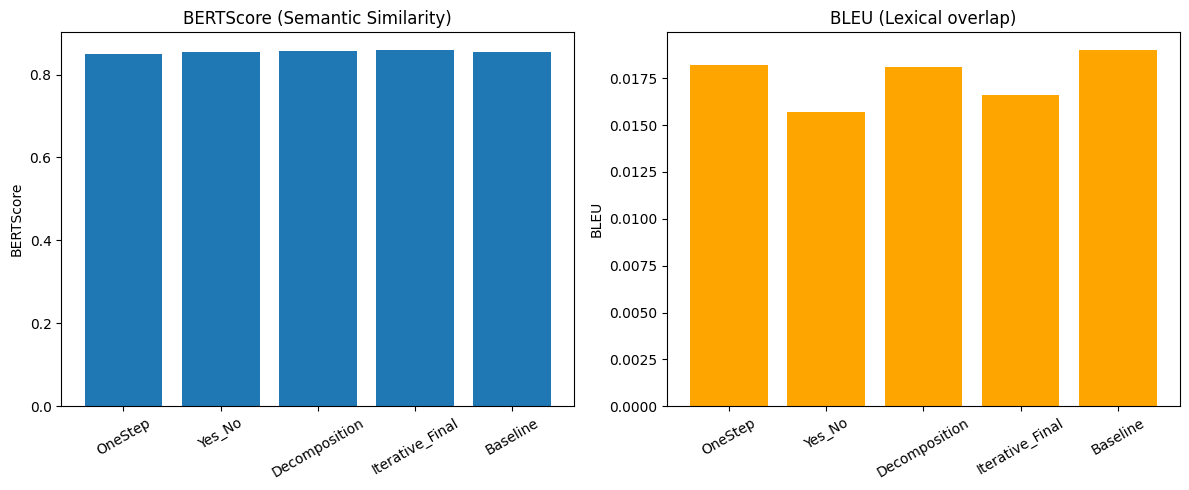

In [44]:
import matplotlib.pyplot as plt

methods = results_table['Method']
method_order = [
    'Baseline',
    'Decomposition',
    'Yes_No',
    'OneStep',
    'Iterative_Final'
]

results_table = results_table.set_index('Method').loc[method_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BERTScore
axes[0].bar(methods, results_table['BERTScore'])
axes[0].set_title("BERTScore (Semantic Similarity)")
axes[0].set_ylabel("BERTScore")
axes[0].tick_params(axis='x', rotation=30)

# BLEU
axes[1].bar(methods, results_table['BLEU'], color='orange')
axes[1].set_title("BLEU (Lexical overlap)")
axes[1].set_ylabel("BLEU")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## NEW EVALUATION METHODS

In [137]:
positive_patterns = [
    r"^\s*i am looking",
    r"i do"
]

negative_patterns = [
    r"\bno\b",
    r"don't know",
    r"dont know",
    r"\bnone\b",
    r"i dont",
    r"i don",
    r"i do not",
    r"i am not",
    r"im not",
    r"not sure",
    r"absolutely not",
    r"i cannot",
    r"i cant",
    r"\bnot\b",
    r"wrong",
    r"\b(irrelevant|irrelevent|unrelated)\b",
    r"i doubt",
    r"i am unsure",
    r"cannot answer",
    r"\b(it\s+)?doesnt matter\b",
    r"i am just",
    r"cannot",
    r"already know",
    r"neither",
    r"this doesnt",
    r"this isnt",
    r"^\s*are\b",
    r"^\s*let\b",
    r"^\s*na\b",
    r"^\s*actually\b"
]


POSITIVE_REGEX = re.compile("|".join(positive_patterns))
NEGATIVE_REGEX = re.compile("|".join(negative_patterns))

def classify_answer(ans):
    ans = str(ans).lower().strip()

    # 1. short answers
    if len(ans.split()) <= 4 and not any(word in ans for word in ["but", "no", "not"]):
        return "positive"

    # 2. strong negatives
    if re.match(r"^\s*(no|n)\b.*\b(i want|i need|show me|tell me|give me|looking for)\b", ans):
        return "negative"
    
    if re.search(r"\b(maybe|possibly|probably|potentially|perhaps)\b.*\bbut\b", ans):
        return "negative"
    
    if re.match(r"^\s*(nope|nop)\b", ans):
        return "negative"

    if re.match(r"^\s*now\b", ans):
        return "negative"

    if re.match(r"^please (answer|look|tell|give)", ans) and len(ans.split()) < 10:
        return "negative"
    
    # Add this after step 2 (strong negatives), before anything else
    if re.match(r"^\s*yes\b", ans):
        return "positive"

    # 3. "i am interested"
    if ans.startswith("i am interested"):
        if any(k in ans for k in ["images", "pictures", "wallpapers", "homepage", "forum"]):
            return "negative"
        return "positive"

    # 4. "just"
    if ans.startswith("just"):
        if any(k in ans for k in ["homepage", "website", "webpage", "site", "take me", "show me"]):
            return "negative"
        return "positive"
    
    # 5. "looking for"
    if ans.startswith("looking for"):
        if any(k in ans for k in ["instructions", "how to", "learn", "guide"]):
            return "positive"
        return "negative"

    # 6. positive starters
    positive_starters = ["i want", "i need", "i would", "i just",
                         "im looking", "id like", "im interested"]
    if any(ans.startswith(s) for s in positive_starters):
        return "positive"

    # 7. only if / sort of / maybe → negative
    if re.match(r"^\s*(only if|sort of|maybe)\b", ans):
        return "negative"

    # 8. generic patterns
    if NEGATIVE_REGEX.search(ans):
        return "negative"

    if POSITIVE_REGEX.search(ans):
        return "positive"

    return "positive"

In [138]:
eval_df = df.copy()

# normalize for safe comparison
q = eval_df['question'].astype(str).str.strip().str.lower()
a = eval_df['answer'].astype(str).str.strip().str.lower()

eval_df = eval_df[
    eval_df['answer'].notna() &
    (a != "") &
    (q != a)
]

In [139]:
eval_df['label'] = eval_df['answer'].apply(classify_answer)
eval_df['label'].value_counts()

label
negative    6400
positive    3873
Name: count, dtype: int64

In [140]:
positive_qs = eval_df[eval_df['label'] == 'positive']['question'].tolist()
negative_qs = eval_df[eval_df['label'] == 'negative']['question'].tolist()

In [141]:
grouped = df.groupby('topic_id')

In [142]:
eval_df.to_csv("labeled_eval_questions.csv", index=False)

In [147]:
from bert_score import score
def compute_pos_neg_score(final_df, df, col):
    pos_scores = []
    neg_scores = []

    for tid in final_df['topic_id'].unique():
        gen_q = final_df[final_df['topic_id'] == tid][col].iloc[0]
        subset = df[df['topic_id'] == tid]

        pos_qs = subset[subset['label'] == 'positive']['question'].tolist()
        neg_qs = subset[subset['label'] == 'negative']['question'].tolist()

        if len(pos_qs) == 0 or len(neg_qs) == 0:
            continue

        _, _, f1_pos = score([gen_q]*len(pos_qs), pos_qs, lang='en', verbose=False)
        _, _, f1_neg = score([gen_q]*len(neg_qs), neg_qs, lang='en', verbose=False)

        pos_scores.append(f1_pos.mean().item())
        neg_scores.append(f1_neg.mean().item())

    return {
        "pos": sum(pos_scores)/len(pos_scores),
        "neg": sum(neg_scores)/len(neg_scores),
        "diff": (sum(pos_scores)/len(pos_scores)) - (sum(neg_scores)/len(neg_scores))
    }

In [148]:
methods = ['Baseline', 'Decomposition', 'Yes_No', 'OneStep', 'Iterative_Final']

posneg_results = {}

for m in methods:
    posneg_results[m] = compute_pos_neg_score(final_df, eval_df, m)

In [149]:
for m, res in posneg_results.items():
    print(f"{m} = Positive: {res['pos']:.4f}, Negative: {res['neg']:.4f}, Diff: {res['diff']:.4f}")

Baseline = Positive: 0.8507, Negative: 0.8490, Diff: 0.0017
Decomposition = Positive: 0.8562, Negative: 0.8547, Diff: 0.0015
Yes_No = Positive: 0.8570, Negative: 0.8564, Diff: 0.0006
OneStep = Positive: 0.8598, Negative: 0.8581, Diff: 0.0017
Iterative_Final = Positive: 0.8558, Negative: 0.8541, Diff: 0.0017


In [150]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def compute_rouge(final_df, eval_df, col):
    pos_scores = []
    neg_scores = []

    for tid in final_df['topic_id'].unique():
        gen_q = final_df[final_df['topic_id'] == tid][col].iloc[0]
        subset = eval_df[eval_df['topic_id'] == tid]

        pos_qs = subset[subset['label'] == 'positive']['question'].tolist()
        neg_qs = subset[subset['label'] == 'negative']['question'].tolist()

        if len(pos_qs) == 0 or len(neg_qs) == 0:
            continue

        pos_f1 = sum(scorer.score(gen_q, ref)['rougeL'].fmeasure for ref in pos_qs) / len(pos_qs)
        neg_f1 = sum(scorer.score(gen_q, ref)['rougeL'].fmeasure for ref in neg_qs) / len(neg_qs)

        pos_scores.append(pos_f1)
        neg_scores.append(neg_f1)

    return {
        "pos": sum(pos_scores)/len(pos_scores),
        "neg": sum(neg_scores)/len(neg_scores),
        "diff": (sum(pos_scores)/len(pos_scores)) - (sum(neg_scores)/len(neg_scores))
    }

In [151]:
methods = ['Baseline', 'Decomposition', 'Yes_No', 'OneStep', 'Iterative_Final']

rouge_results = {}

for m in methods:
    rouge_results[m] = compute_rouge(final_df, eval_df, m)

In [152]:
for m, res in rouge_results.items():
    print(f"{m} = Positive: {res['pos']:.4f}, Negative: {res['neg']:.4f}, Diff: {res['diff']:.4f}")

Baseline = Positive: 0.1807, Negative: 0.1758, Diff: 0.0049
Decomposition = Positive: 0.1797, Negative: 0.1712, Diff: 0.0085
Yes_No = Positive: 0.1854, Negative: 0.1815, Diff: 0.0039
OneStep = Positive: 0.1968, Negative: 0.1905, Diff: 0.0063
Iterative_Final = Positive: 0.1978, Negative: 0.1873, Diff: 0.0104


In [153]:
# final results table
results_table = []

for m in methods:
    bert = posneg_results[m]
    rouge = rouge_results[m]
    results_table.append({
        "Method": m,
        "BERT_Pos": bert['pos'],
        "BERT_Neg": bert['neg'],
        "BERT_Diff": bert['diff'],
        "ROUGE_Pos": rouge['pos'],
        "ROUGE_Neg": rouge['neg'],
        "ROUGE_Diff": rouge['diff'],
    })

results_df = pd.DataFrame(results_table).round(4)

In [154]:
# Save results to CSV
results_df.to_csv("final_metrics_table_new.csv", index=False)
print("Saved final_metrics_table_new.csv")

Saved final_metrics_table_new.csv


In [87]:
# sample 50 queries for human annotation
df = pd.read_csv("final_results_iterative_eval.csv", sep=",")

sample_df = df.sample(n=50, random_state=42)

sample_df.to_csv("sample_50_rows.csv", index=False)

# Cohen's Kappa

In [297]:
human_df = pd.read_csv("Survey Responses.csv")
human_df.head(1)

,Timestamp,Respondent ID,Topic,Question Text,Fluency,Relevance,Usefulness
0,4/27/2026 16:02:06,R1777296599077351,Porterville,What is Porterville known for in terms of its economy or industry?,5,3,3


In [298]:
human_df["Topic"] = human_df["Topic"].str.lower()
human_df["Question Text"] = human_df["Question Text"].str.strip()

In [299]:
human_df.head()

,Timestamp,Respondent ID,Topic,Question Text,Fluency,Relevance,Usefulness
0,4/27/2026 16:02:06,R1777296599077351,porterville,What is Porterville known for in terms of its economy or industry?,5,3,3
1,4/27/2026 16:02:06,R1777296599077351,porterville,Is Porterville a city in California?,5,4,3
2,4/27/2026 16:02:07,R1777296599077351,porterville,"Is Porterville a specific city or location you're referring to, such as in California?",5,4,3
3,4/27/2026 16:02:07,R1777296599077351,porterville,What is the intended meaning of porterville?,5,1,5
4,4/27/2026 16:02:08,R1777296599077351,porterville,What is Porterville's primary economic industry?,5,2,4


In [300]:
sample_df = pd.read_csv("sample_50_rows.csv")

In [301]:
sample_df["topic"] = sample_df["topic"].str.lower()

for col in ['Baseline', 'Decomposition', 'Yes_No', 'OneStep', 'Iterative_Final']:
    sample_df[col] = sample_df[col].str.strip()

In [302]:
mapping = []

methods = ['Baseline', 'Decomposition', 'Yes_No', 'OneStep', 'Iterative_Final']

for _, row in sample_df.iterrows():
    for method in methods:
        
        # skip duplicate OneStep if same as Iterative_Final
        if method == "OneStep" and row["OneStep"] == row["Iterative_Final"]:
            continue
        
        mapping.append({
            "Topic": row["topic"],
            "Question Text": row[method],
            "method": method
        })

mapping_df = pd.DataFrame(mapping)

In [291]:
human_kappa_df = human_df.merge(
    mapping_df,
    on=["Topic", "Question Text"],
    how="left"
)

In [306]:
human_kappa_df["method"].isna().sum()

np.int64(0)

In [307]:
human_kappa_df["item_id"] = (
    human_kappa_df["Topic"] + " || " + 
    human_kappa_df["Question Text"] + " || " + 
    human_kappa_df["method"]
)

In [308]:
human_kappa_df.head()

,Timestamp,Respondent ID,Topic,Question Text,Fluency,Relevance,Usefulness,method,item_id
0,4/27/2026 16:02:06,R1777296599077351,porterville,What is Porterville known for in terms of its economy or industry?,5,3,3,Decomposition,porterville || What is Porterville known for in terms of its economy or industry? || Decomposition
1,4/27/2026 16:02:06,R1777296599077351,porterville,Is Porterville a city in California?,5,4,3,Yes_No,porterville || Is Porterville a city in California? || Yes_No
2,4/27/2026 16:02:07,R1777296599077351,porterville,"Is Porterville a specific city or location you're referring to, such as in California?",5,4,3,Baseline,"porterville || Is Porterville a specific city or location you're referring to, such as in California? || Baseline"
3,4/27/2026 16:02:07,R1777296599077351,porterville,What is the intended meaning of porterville?,5,1,5,OneStep,porterville || What is the intended meaning of porterville? || OneStep
4,4/27/2026 16:02:08,R1777296599077351,porterville,What is Porterville's primary economic industry?,5,2,4,Iterative_Final,porterville || What is Porterville's primary economic industry? || Iterative_Final


In [309]:
from statsmodels.stats.inter_rater import fleiss_kappa

In [310]:
import numpy as np

def prepare_fleiss(df, metric):
    pivot = df.pivot_table(
        index="item_id",
        columns="Respondent ID",
        values=metric
    ).dropna()

    categories = [1, 2, 3, 4, 5]
    matrix = []

    for _, row in pivot.iterrows():
        counts = [sum(row == c) for c in categories]
        matrix.append(counts)

    return np.array(matrix)

In [311]:
fluency_mat = prepare_fleiss(human_kappa_df, "Fluency")
relevance_mat = prepare_fleiss(human_kappa_df, "Relevance")
usefulness_mat = prepare_fleiss(human_kappa_df, "Usefulness")

fluency_fleiss = fleiss_kappa(fluency_mat)
relevance_fleiss = fleiss_kappa(relevance_mat)
usefulness_fleiss = fleiss_kappa(usefulness_mat)

fluency_fleiss, relevance_fleiss, usefulness_fleiss

(np.float64(-0.00880428062845124),
 np.float64(0.019730422558504913),
 np.float64(0.0040383475504471595))

In [254]:
from sklearn.metrics import cohen_kappa_score

def compute_kappa(df, metric):
    pivot = df.pivot_table(
        index="item_id",
        columns="Respondent ID",
        values=metric
    ).dropna()

    annotators = pivot.columns
    kappas = []

    for i in range(len(annotators)):
        for j in range(i+1, len(annotators)):
            k = cohen_kappa_score(
                pivot[annotators[i]],
                pivot[annotators[j]]
            )
            kappas.append(k)

    return sum(kappas) / len(kappas)

In [255]:
fluency_kappa = compute_kappa(human_kappa_df, "Fluency")
relevance_kappa = compute_kappa(human_kappa_df, "Relevance")
usefulness_kappa = compute_kappa(human_kappa_df, "Usefulness")

kappa_df = pd.DataFrame({
    "Metric": ["Fluency", "Relevance", "Usefulness"],
    "Kappa": [fluency_kappa, relevance_kappa, usefulness_kappa]
})

kappa_df

,Metric,Kappa
0,Fluency,0.056240
1,Relevance,0.070843
2,Usefulness,0.043718


In [279]:
from sklearn.metrics import cohen_kappa_score

pivot = human_kappa_df.pivot_table(
    index="item_id",
    columns="Respondent ID",
    values="Fluency"
).dropna()

cols = pivot.columns

print("Fluency:")
print("Annotator 1 vs 2:", cohen_kappa_score(pivot[cols[0]], pivot[cols[1]]))
print("Annotator 1 vs 3:", cohen_kappa_score(pivot[cols[0]], pivot[cols[2]]))
print("Annotator 2 vs 3:", cohen_kappa_score(pivot[cols[1]], pivot[cols[2]]))

Fluency:
Annotator 1 vs 2: 0.03934451573007669
Annotator 1 vs 3: 0.0017626547112695734
Annotator 2 vs 3: 0.12761357998440714


In [280]:
pivot = human_kappa_df.pivot_table(
    index="item_id",
    columns="Respondent ID",
    values="Relevance"
).dropna()

In [281]:
print("Relevance:")
print("Annotator 1 vs 2:", cohen_kappa_score(pivot[cols[0]], pivot[cols[1]]))
print("Annotator 1 vs 3:", cohen_kappa_score(pivot[cols[0]], pivot[cols[2]]))
print("Annotator 2 vs 3:", cohen_kappa_score(pivot[cols[1]], pivot[cols[2]]))

Relevance:
Annotator 1 vs 2: 0.12949715693210706
Annotator 1 vs 3: 0.0046400036214662155
Annotator 2 vs 3: 0.07839247503566327


In [282]:
pivot = human_kappa_df.pivot_table(
    index="item_id",
    columns="Respondent ID",
    values="Usefulness"
).dropna()

In [283]:
print("Usefulness:")
print("Annotator 1 vs 2:", cohen_kappa_score(pivot[cols[0]], pivot[cols[1]]))
print("Annotator 1 vs 3:", cohen_kappa_score(pivot[cols[0]], pivot[cols[2]]))
print("Annotator 2 vs 3:", cohen_kappa_score(pivot[cols[1]], pivot[cols[2]]))

Usefulness:
Annotator 1 vs 2: 0.02163410048313774
Annotator 1 vs 3: 0.06196734547411853
Annotator 2 vs 3: 0.04755183793769058


In [267]:
from sklearn.metrics import cohen_kappa_score

cols = pivot.columns

print("Annotator 1 vs 2:", cohen_kappa_score(pivot[cols[0]], pivot[cols[1]]))
print("Annotator 1 vs 3:", cohen_kappa_score(pivot[cols[0]], pivot[cols[2]]))
print("Annotator 2 vs 3:", cohen_kappa_score(pivot[cols[1]], pivot[cols[2]]))

NameError: name 'pivot' is not defined

In [256]:
from scipy.stats import spearmanr

def compute_spearman(df, metric):
    pivot = df.pivot_table(
        index="item_id",
        columns="Respondent ID",
        values=metric
    ).dropna()

    annotators = pivot.columns
    corrs = []

    for i in range(len(annotators)):
        for j in range(i+1, len(annotators)):
            corr, _ = spearmanr(
                pivot[annotators[i]],
                pivot[annotators[j]]
            )
            corrs.append(corr)

    return sum(corrs) / len(corrs)

In [257]:
fluency_spear = compute_spearman(human_kappa_df, "Fluency")
relevance_spear = compute_spearman(human_kappa_df, "Relevance")
usefulness_spear = compute_spearman(human_kappa_df, "Usefulness")

In [258]:
print(f"Fluency Spearman: {fluency_spear:.3f}")
print(f"Relevance Spearman: {relevance_spear:.3f}")
print(f"Usefulness Spearman: {usefulness_spear:.3f}")

Fluency Spearman: 0.143
Relevance Spearman: 0.221
Usefulness Spearman: 0.243


# LLM as a judge

In [323]:
df = pd.read_csv("final_results_iterative_eval.csv")

In [326]:
methods = ['Baseline', 'Decomposition', 'Yes_No', 'OneStep', 'Iterative_Final']

long_full_df = []

for _, row in df.iterrows():
    for method in methods:
        
        # skip duplicate
        if method == "OneStep" and row["OneStep"] == row["Iterative_Final"]:
            continue
        
        long_full_df.append({
            "topic_id": row["topic_id"],
            "topic": row["topic"],
            "method": method,
            "question": row[method]
        })

long_full_df = pd.DataFrame(long_full_df)

In [327]:
long_full_df.head()

,topic_id,topic,method,question
0,1,obama family tree,Baseline,"Was Barack Obama's father, Barack Obama Sr., Kenyan or American?"
1,1,obama family tree,Decomposition,Who is Barack Obama's wife in his first marriage?
2,1,obama family tree,Yes_No,Is Barack Obama's father still alive?
3,1,obama family tree,OneStep,What is the ancestry of Barack Obama's paternal grandfather?
4,1,obama family tree,Iterative_Final,What other family members are included in Barack Obama's immediate family tree?


In [331]:
long_full_df.shape

(936, 4)

In [332]:
test_llm_df = long_full_df.sample(10, random_state=42)

In [334]:
def build_judge_prompt(query, question):
    return f"""
You are evaluating a follow-up question for a user query.

User Query:
{query}

Generated Follow-up Question:
{question}

Rate the question on a scale of 1 (poor) to 5 (excellent).

A score of:
1 = very poor
2 = poor
3 = average
4 = good
5 = excellent

Fluency: Is the question clearly written, grammatically correct, and natural?

Relevance: Does the question directly address the user's query and its intent or ambiguity?

Usefulness: Would the answer to this question help clarify what the user is looking for?

Be consistent and use the full range of scores.

Return ONLY this JSON:
{{"fluency": X, "relevance": X, "usefulness": X}}
"""

In [335]:
def evaluate_llm(query, question):
    prompt = build_judge_prompt(query, question)

    response = ollama.chat(
        model='qwen2.5:7b',
        messages=[{"role": "user", "content": prompt}]
    )

    text = response['message']['content']

    try:
        return json.loads(text)
    except:
        return {"fluency": None, "relevance": None, "usefulness": None}

In [337]:
row = test_llm_df.iloc[0]

evaluate_llm(row["topic"], row["question"])

{'fluency': 4, 'relevance': 5, 'usefulness': 5}

In [338]:
results = []

for _, row in test_llm_df.iterrows():
    scores = evaluate_llm(row["topic"], row["question"])
    
    results.append({
        "topic_id": row["topic_id"],
        "method": row["method"],
        **scores
    })

In [339]:
results_df = pd.DataFrame(results)

results_df.head()

,topic_id,method,fluency,relevance,usefulness
0,162,Yes_No,4,3,2
1,113,Yes_No,4,3,2
2,140,Iterative_Final,5,5,5
3,45,OneStep,4,3,2
4,50,Iterative_Final,5,5,5


In [340]:
# std_scores = results_df.groupby("method")[["fluency", "relevance", "usefulness"]].std().reset_index()

# std_scores

In [ ]:
# LLM as a judge on all queries
results = []

for _, row in long_full_df.iterrows():
    scores = evaluate_llm(row["topic"], row["question"])
    
    # skip bad outputs
    if not scores:
        continue
    
    results.append({
        "topic_id": row["topic_id"],
        "topic": row["topic"],
        "method": row["method"],
        "question": row["question"],
        "fluency": scores.get("fluency"),
        "relevance": scores.get("relevance"),
        "usefulness": scores.get("usefulness")
    })

full_llm_df = pd.DataFrame(results)

In [ ]:
full_llm_df.to_csv("llm_judge_full.csv", index=False)

In [ ]:
full_scores = (
    full_llm_df
    .groupby("method")[["fluency", "relevance", "usefulness"]]
    .mean()
    .reset_index()
)

full_scores

In [ ]:
sample_df = pd.read_csv("sample_50_rows.csv")

In [ ]:
# Same 50 queries as human evaluation for LLM judge comparison
sample_llm_df = full_llm_df[
    full_llm_df["topic_id"].isin(sample_df["topic_id"])
]

In [ ]:
# Aggregate 50 (for correlation)
sample_llm_scores = (
    sample_llm_df
    .groupby("method")[["fluency", "relevance", "usefulness"]]
    .mean()
    .reset_index()
)

# Human vs LLM correlation

In [ ]:
human_scores = (
    human_kappa_df
    .groupby("method")[["Fluency", "Relevance", "Usefulness"]]
    .mean()
    .reset_index()
)

In [ ]:
llm_scores = sample_llm_scores.rename(columns={
    "fluency": "Fluency",
    "relevance": "Relevance",
    "usefulness": "Usefulness"
})

In [ ]:
compare_df = human_scores.merge(
    llm_scores,
    on="method",
    suffixes=("_human", "_llm")
)

compare_df

,method,Fluency_human,Relevance_human,Usefulness_human,Fluency_llm,Relevance_llm,Usefulness_llm
0,Baseline,4.793333,4.200000,3.960000,4.360000,4.040000,3.68000
1,Decomposition,4.826667,3.953333,3.646667,4.120000,3.920000,3.42000
2,Iterative_Final,4.706667,3.886667,3.626667,3.960000,3.580000,2.98000
3,OneStep,4.435897,3.170940,3.025641,3.923077,3.717949,3.25641
4,Yes_No,4.840000,3.793333,3.386667,3.940000,3.540000,2.86000


In [ ]:
corr = compare_df.corr(numeric_only=True)
corr

,Fluency_human,Relevance_human,Usefulness_human,Fluency_llm,Relevance_llm,Usefulness_llm
Fluency_human,1.000000,0.867548,0.725692,0.438126,0.176701,0.021088
Relevance_human,0.867548,1.000000,0.970419,0.732398,0.449890,0.341698
Usefulness_human,0.725692,0.970419,1.000000,0.827413,0.581131,0.502744
Fluency_llm,0.438126,0.732398,0.827413,1.000000,0.900036,0.866617
Relevance_llm,0.176701,0.449890,0.581131,0.900036,1.000000,0.985173
Usefulness_llm,0.021088,0.341698,0.502744,0.866617,0.985173,1.000000


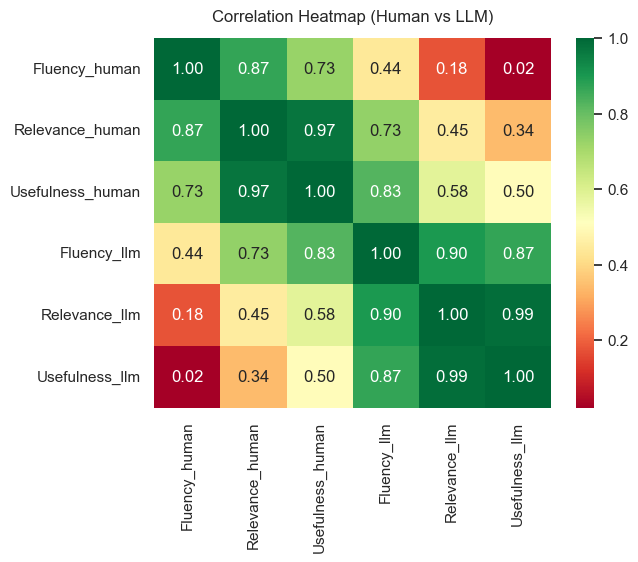

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = compare_df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Correlation Heatmap (Human vs LLM)", pad=12)
plt.show()